# RF Tx → Rx chain end-to-end simulation

Build a discrete-time model of the full transmitter → channel → receiver chain
at RF, including the carrier mixers. Each LO has its own **frequency offset**,
**time shift**, and **phase**, so we can study how each mismatch propagates
to baseband Rx.

## Pipeline

1. **Baseband Tx** — generate $N = 80$ orthogonal tones at $\Delta f = 1$ MHz
   spacing in the frequency domain, IFFT to time domain.
2. **Upconvert** — multiply by the Tx LO carrier
   $\exp\bigl(j[\,2\pi f_{TX}(t - t_{TX}) + \varphi_{TX}\,]\bigr)$
   (with $f_{TX} = f_{LO} + \delta f_{TX}$), then take the real part —
   this is the I/Q upconversion model that produces a single real-valued
   RF signal (what would actually go on the antenna).
3. **Propagation channel** — distance $d$ → delay $\tau = d/c$, applied as
   $s_{RF}^{\text{rx}}(t) = s_{RF}(t - \tau)$ via a spectral phase ramp.
4. **Downconvert** — multiply by the Rx LO conjugate carrier
   $\exp\bigl(-j[\,2\pi f_{RX}(t - t_{RX}) + \varphi_{RX}\,]\bigr)$
   (with $f_{RX} = f_{LO} + \delta f_{RX}$), then **LPF** to remove the
   sum-frequency image at $\sim 2 f_{LO}$. Result is complex baseband.
5. **Verify** — compare the recovered baseband against the analytical
   prediction $\hat y_{BB}(t) = s_{BB}(t-\tau)\,\exp(j[2\pi\,\delta f\,t + \Delta\varphi - 2\pi f_{TX}\tau])$
   where $\delta f = f_{TX} - f_{RX}$ and $\Delta\varphi$ is the constant
   phase offset accumulated through both LOs.
6. **Estimate distance with MUSIC** — sample per-tone phasors
   $y_k = \mathrm{FFT}\{y_{BB}\}[k]$.
## Setup constants

- $N = 80$ tones, $\Delta f = 1$ MHz → symbol duration $T = 1/\Delta f = 1$ µs.
- Carrier $f_{LO} = 2.4$ GHz (BLE / WiFi 2.4 GHz band nominal).
- Sample rate $f_s = 10$ GHz (so $M = T \cdot f_s = 10000$ samples per symbol;
  Nyquist for the carrier + signal bandwidth holds with margin).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Multitone parameters
N        = 80                    # number of orthogonal tones
delta_f  = 1e6                   # tone spacing, Hz
T_sym    = 1.0 / delta_f         # symbol duration, s (= 1 µs)

# Carrier
f_LO     = 2.4e9                 # nominal carrier, Hz

# Tx LO offsets
delta_f_TX_ppm = 0.0             # Tx LO frequency offset, ppm of f_LO
delta_f_TX     = delta_f_TX_ppm * f_LO * 1e-6   # Hz
t_TX           = 11e-9           # Tx LO time shift, s
phi_TX         = 0.30            # Tx LO phase, rad

# Rx LO offsets
delta_f_RX_ppm = 0.0              # Rx LO frequency offset, ppm of f_LO
delta_f_RX     = delta_f_RX_ppm * f_LO * 1e-6   # Hz
t_RX           = -0.1e-9          # Rx LO time shift, s
phi_RX         = -1.7             # Rx LO phase, rad

# RF sample rate (Nyquist for f_LO + signal-BW with margin)
fs = 10e9                        # 10 GHz sample rate
M  = int(round(T_sym * fs))      # samples per symbol = 10000
t  = np.arange(M) / fs           # RF time grid
freqs = np.fft.fftfreq(M, d=1/fs)
freqs_shifted = np.fft.fftshift(freqs)

print(f"N = {N}, delta_f = {delta_f/1e6:g} MHz, T_sym = {T_sym*1e6:g} µs")
print(f"f_LO = {f_LO/1e9:g} GHz, fs = {fs/1e9:g} GHz, M = {M} samples")
print(f"f_TX = {(f_LO + delta_f_TX)/1e9:.9f} GHz  "
      f"(δf_TX = {delta_f_TX_ppm:+.1f} ppm = {delta_f_TX:+.1f} Hz)")
print(f"f_RX = {(f_LO + delta_f_RX)/1e9:.9f} GHz  "
      f"(δf_RX = {delta_f_RX_ppm:+.1f} ppm = {delta_f_RX:+.1f} Hz)")
print(f"residual delta_f = {delta_f_TX - delta_f_RX:.1f} Hz  "
      f"({delta_f_TX_ppm - delta_f_RX_ppm:+.1f} ppm)")

N = 80, delta_f = 1 MHz, T_sym = 1 µs
f_LO = 2.4 GHz, fs = 10 GHz, M = 10000 samples
f_TX = 2.400000000 GHz  (δf_TX = +0.0 ppm = +0.0 Hz)
f_RX = 2.400000000 GHz  (δf_RX = +0.0 ppm = +0.0 Hz)
residual delta_f = 0.0 Hz  (+0.0 ppm)


## 1. Baseband Tx — N orthogonal tones

Place unit magnitude on FFT bins $k = 0, 1, \dots, N-1$ (frequencies
$0, \Delta f, \dots, (N-1)\Delta f$). Take the IFFT to get the
time-domain baseband signal $s_{BB}(t)$.

Note: bin $k$ corresponds to frequency $k \cdot f_s / M = k \cdot \Delta f$
because $f_s/M = \Delta f$ by construction. So our 80 tones live on the
first 80 of the 10000 FFT bins, leaving the remaining bins (the band
above 80 MHz, all the way up to $f_s/2 = 5$ GHz) at zero — that's the
RF guard band the upconverter operates in.

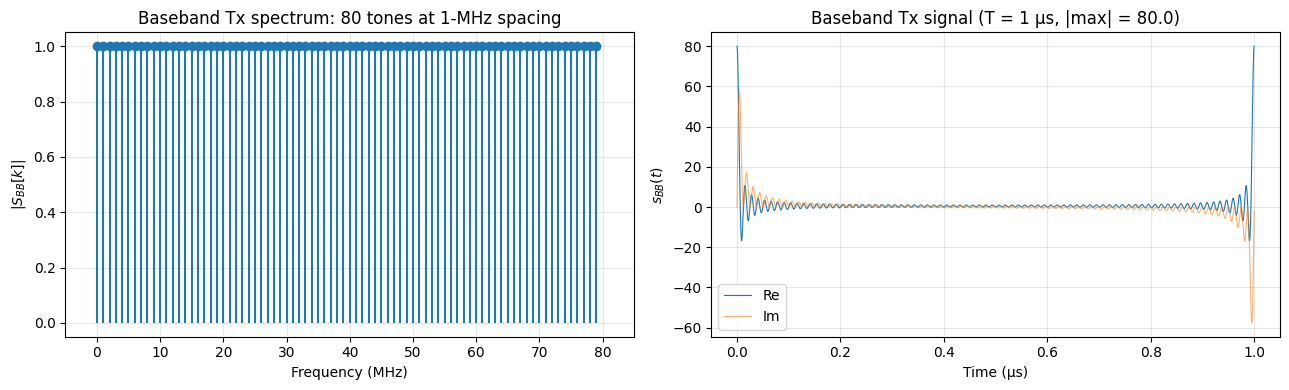

In [2]:
# Baseband Tx: unit magnitude on FFT bins 0..N-1
S_BB = np.zeros(M, dtype=np.complex128)
S_BB[:N] = 1.0
s_BB = np.fft.ifft(S_BB) * M  # scale so each tone has unit amplitude in time

# Plot baseband spectrum (linear) and time-domain signal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
tone_freqs_MHz = np.arange(N) * delta_f / 1e6
ax.stem(tone_freqs_MHz, np.abs(S_BB[:N]), basefmt=' ')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel(r'$|S_{BB}[k]|$')
ax.set_title(f'Baseband Tx spectrum: {N} tones at {delta_f/1e6:g}-MHz spacing')
ax.set_xlim(-5, N * delta_f / 1e6 + 5)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t * 1e6, np.real(s_BB), label='Re', linewidth=0.8)
ax.plot(t * 1e6, np.imag(s_BB), label='Im', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Time (µs)')
ax.set_ylabel(r'$s_{BB}(t)$')
ax.set_title(f'Baseband Tx signal (T = {T_sym*1e6:g} µs, |max| = {np.max(np.abs(s_BB)):.1f})')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 2. Upconvert to RF — Tx LO with offset, time, and phase

The I/Q upconversion model:

$$
s_{RF}(t) \;=\; \mathrm{Re}\bigl\{\,s_{BB}(t)\,\cdot\,\exp\bigl(j[2\pi f_{TX}(t - t_{TX}) + \varphi_{TX}]\bigr)\,\bigr\}.
$$

Three parameters of the Tx LO:

- **Frequency offset $\delta f_{TX}$** — Tx LO is at $f_{TX} = f_{LO} + \delta f_{TX}$
  rather than nominal. Comes from crystal frequency tolerance.
- **Time shift $t_{TX}$** — Tx LO clock skew (cable delays, processing
  latency, hardware offset between Tx data path and Tx mixer clock).
- **Phase $\varphi_{TX}$** — initial LO phase at $t = 0$; depends on PLL
  start-up state.

The Re{·} extraction generates a **two-sided spectrum** at $\pm f_{TX}$ — the
positive-frequency band is the desired upconverted signal, the negative
band is the conjugate image. A real antenna emits both.

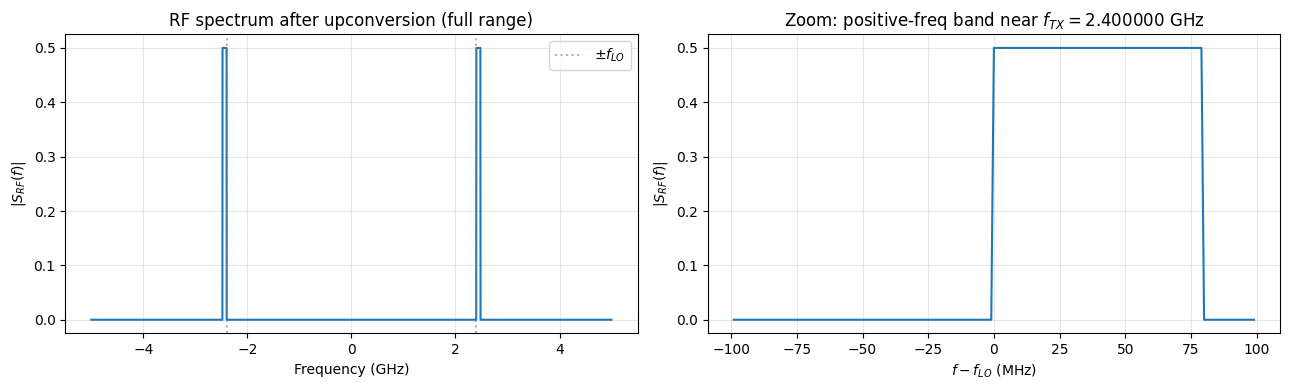

In [3]:
# Upconvert: I/Q modulator with Tx LO offset/time/phase
f_TX  = f_LO + delta_f_TX
lo_TX = np.exp(1j * (2 * np.pi * f_TX * (t - t_TX) + phi_TX))
s_RF  = np.real(s_BB * lo_TX)   # real-valued antenna signal

S_RF = np.fft.fft(s_RF)

# Plot RF spectrum (full and zoom around +f_TX)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(freqs_shifted / 1e9, np.abs(np.fft.fftshift(S_RF)) / M)
ax.axvline( f_LO / 1e9, color='gray', linestyle=':', alpha=0.6, label=f'$\\pm f_{{LO}}$')
ax.axvline(-f_LO / 1e9, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel(r'$|S_{RF}(f)|$')
ax.set_title('RF spectrum after upconversion (full range)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
mask = np.abs(freqs_shifted - f_TX) < 100e6
ax.plot((freqs_shifted[mask] - f_LO) / 1e6, np.abs(np.fft.fftshift(S_RF))[mask] / M)
ax.set_xlabel(r'$f - f_{LO}$ (MHz)')
ax.set_ylabel(r'$|S_{RF}(f)|$')
ax.set_title(f'Zoom: positive-freq band near $f_{{TX}} = {f_TX/1e9:.6f}$ GHz')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.5 Propagation channel — Tx → Rx delay

Insert a propagation channel between the Tx antenna and the Rx antenna.
Distance $d$ → delay $\tau = d/c$. The RF signal arriving at the Rx is the
Tx signal delayed:

$$
s_{RF}^{\text{rx}}(t) \;=\; s_{RF}(t - \tau).
$$

In the discrete-time simulation we apply this delay via a **spectral phase
ramp**:

$$
\widetilde{S}_{RF}(f) \;=\; S_{RF}(f)\,\exp(-j\,2\pi f \tau).
$$


In [4]:
# 2.5 Propagation channel: delay s_RF by tau = d/c via a spectral phase ramp
c      = 2.998e8                 # speed of light, m/s
d_true = 10.0                    # Tx-Rx distance, m
tau    = d_true / c              # propagation delay, s

S_RF_full    = np.fft.fft(s_RF)
delay_phasor = np.exp(-1j * 2 * np.pi * freqs * tau)
s_RF_rx      = np.real(np.fft.ifft(S_RF_full * delay_phasor))

print(f"Distance d = {d_true} m  ->  delay tau = {tau*1e9:.4f} ns "
      f"({tau * fs:.2f} samples at fs = {fs/1e9:g} GHz)")

Distance d = 10.0 m  ->  delay tau = 33.3556 ns (333.56 samples at fs = 10 GHz)


## 3. Downconvert at Rx — Rx LO with different offset, time, and phase

Mix the delayed RF signal $s_{RF}^{\text{rx}}(t) = s_{RF}(t - \tau)$ with
the conjugate of the Rx LO:

$$
y_{\text{mixed}}(t) \;=\; s_{RF}^{\text{rx}}(t)\,\cdot\,2\,\exp\bigl(-j[2\pi f_{RX}(t - t_{RX}) + \varphi_{RX}]\bigr),
$$

then apply an LPF to keep only frequencies $|f| < N\,\Delta f = 80$ MHz.
The factor of 2 compensates for the $1/2$ that came from the Re{·}
extraction at the Tx, so the recovered baseband has the same magnitude as
the original $s_{BB}$ at zero LO mismatch.

The mixer output has two bands:

- **Sum band** at $\pm(f_{TX} + f_{RX}) \approx \pm 4.8$ GHz — image to be
  rejected by the LPF.
- **Difference band** near $\pm(f_{TX} - f_{RX}) = \pm \delta f$ — this is
  our baseband, slightly shifted by the residual carrier offset
  $\delta f = \delta f_{TX} - \delta f_{RX}$.

After LPF, only the difference band survives.

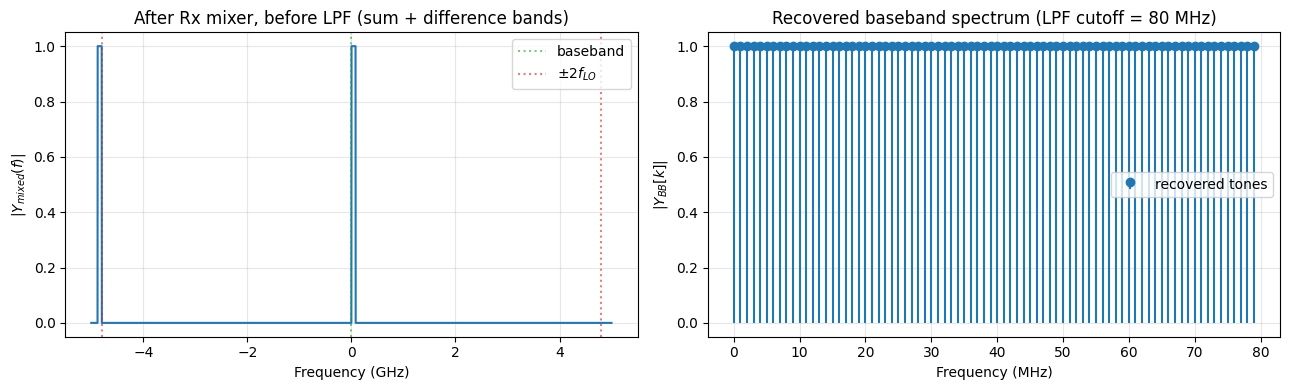

In [5]:
# Downconvert: mix with Rx LO conjugate, then LPF
f_RX  = f_LO + delta_f_RX
lo_RX = np.exp(-1j * (2 * np.pi * f_RX * (t - t_RX) + phi_RX))
y_mixed = s_RF_rx * 2 * lo_RX     # factor 2 compensates for the 1/2 from Re{·}

# LPF: zero out FFT bins above the baseband cutoff (N * delta_f).
Y_mixed = np.fft.fft(y_mixed)
cutoff = N * delta_f              # 80 MHz
Y_BB   = Y_mixed.copy()
Y_BB[np.abs(freqs) > cutoff] = 0.0
y_BB   = np.fft.ifft(Y_BB)

# Plot mixer-output spectrum (before LPF) and recovered baseband spectrum
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(freqs_shifted / 1e9, np.abs(np.fft.fftshift(Y_mixed)) / M)
ax.axvline(0, color='C2', linestyle=':', alpha=0.6, label='baseband')
ax.axvline( 2 * f_LO / 1e9, color='C3', linestyle=':', alpha=0.6, label=r'$\pm 2 f_{LO}$')
ax.axvline(-2 * f_LO / 1e9, color='C3', linestyle=':', alpha=0.6)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel(r'$|Y_{mixed}(f)|$')
ax.set_title('After Rx mixer, before LPF (sum + difference bands)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.stem(np.arange(N) * delta_f / 1e6,
        np.abs(Y_BB[:N]) / M, basefmt=' ', label='recovered tones')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel(r'$|Y_{BB}[k]|$')
ax.set_title(f'Recovered baseband spectrum (LPF cutoff = {cutoff/1e6:g} MHz)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Verify chain — compare to analytical prediction

After upconvert + propagation delay $\tau$ + downconvert + LPF, the
recovered baseband should be:

$$
y_{BB}(t) \;=\; s_{BB}(t - \tau)\,\cdot\,\exp\!\bigl(j[\,2\pi\,\delta f\,t + \Delta\varphi - 2\pi f_{TX}\,\tau\,]\bigr)
$$

where:

- $\delta f = f_{TX} - f_{RX} = \delta f_{TX} - \delta f_{RX}$
  (residual carrier offset).
- $\Delta\varphi = -2\pi\,f_{TX}\,t_{TX} + 2\pi\,f_{RX}\,t_{RX} + \varphi_{TX} - \varphi_{RX}$
  (constant phase accumulated through both LOs; combines time-shifts and
  initial phases).
- $-2\pi f_{TX} \tau$ is the additional **carrier phase** the propagation
  delay imprints on top of the baseband time-shift.

The chain output should match this prediction.

Residual frequency offset: 0.0000 Hz
Carrier phase from delay : -5.0299e+02 rad
Total phase   (wrapped)  : -2.356565 rad (unwrapped: -6.6837e+02)
Max error magnitude: 8.661e-11
RMS error magnitude: 7.956e-12
Signal RMS magnitude: 8.944e+00


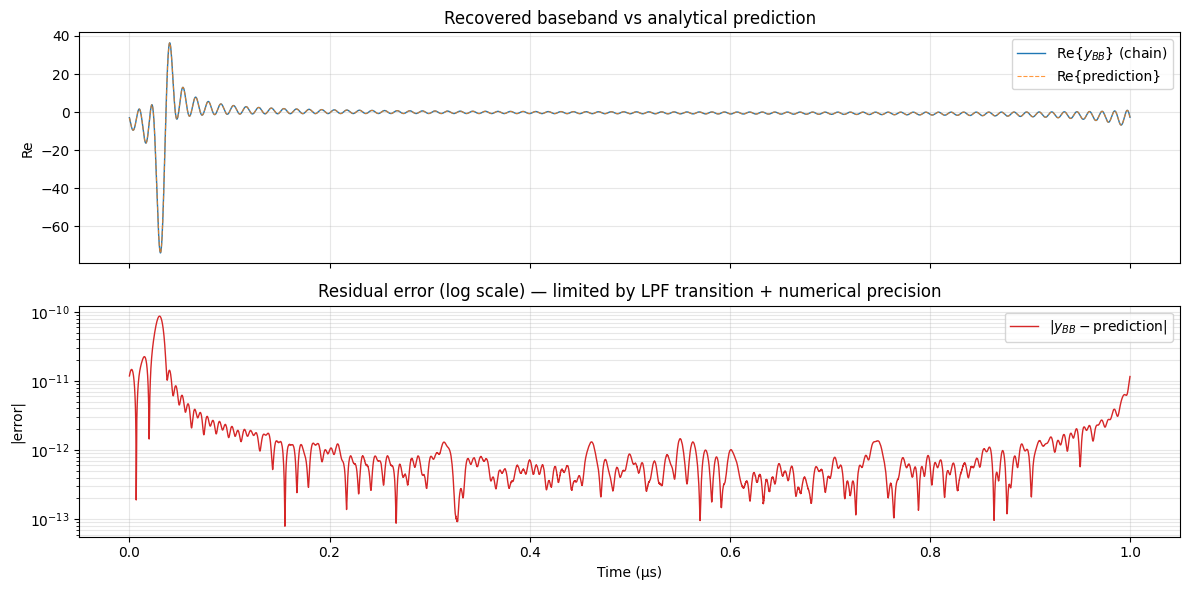

In [6]:
# Analytical prediction
delta_f_resid = f_TX - f_RX        # residual carrier offset
phi_resid     = (-2*np.pi*f_TX*t_TX + 2*np.pi*f_RX*t_RX + phi_TX - phi_RX)
phi_carrier   = -2*np.pi*f_TX*tau  # extra carrier phase from propagation delay
phi_total     = phi_resid + phi_carrier
phi_total_wrapped = np.angle(np.exp(1j * phi_total))   # wrap to (-pi, pi]

print(f"Residual frequency offset: {delta_f_resid:.4f} Hz")
print(f"Carrier phase from delay : {phi_carrier:+.4e} rad")
print(f"Total phase   (wrapped)  : {phi_total_wrapped:+.6f} rad "
      f"(unwrapped: {phi_total:+.4e})")

# s_BB(t - tau) via the same spectral phase ramp used on s_RF
S_BB_full    = np.fft.fft(s_BB)
s_BB_delayed = np.fft.ifft(S_BB_full * np.exp(-1j * 2*np.pi*freqs*tau))
y_BB_pred = s_BB_delayed * np.exp(1j * (2*np.pi*delta_f_resid*t + phi_total))


# Quantitative check
err = y_BB - y_BB_pred
print(f"Max error magnitude: {np.max(np.abs(err)):.3e}")
print(f"RMS error magnitude: {np.sqrt(np.mean(np.abs(err)**2)):.3e}")
print(f"Signal RMS magnitude: {np.sqrt(np.mean(np.abs(y_BB)**2)):.3e}")

# Plot: real parts of recovered vs predicted
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(t * 1e6, np.real(y_BB),      label=r'Re{$y_{BB}$} (chain)',     linewidth=1.0)
ax.plot(t * 1e6, np.real(y_BB_pred), label=r'Re{prediction}', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_ylabel('Re')
ax.set_title('Recovered baseband vs analytical prediction')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t * 1e6, np.abs(err),        label=r'$|y_{BB} - \mathrm{prediction}|$', color='C3', linewidth=1.0)
ax.set_yscale('log')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('|error|')
ax.set_title('Residual error (log scale) — limited by LPF transition + numerical precision')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Per-tone phasor view

The chain output $y_{BB}(t)$ already encodes the propagation delay (the
channel was applied in Section 2.5). Sample the recovered baseband on the
tone grid by reading FFT bins $k = 0, \dots, N-1$:

$$
y_k \;=\; \mathrm{FFT}\{y_{BB}\}[k] / M.
$$

Each tone's phase carries the cumulative path phase
$\arg(y_k) \;=\; -2\pi\,k\,\Delta f\,\tau \;+\; \text{const}$
where the constant absorbs the carrier-phase prefactor $-2\pi f_{TX}\tau$,
the LO-mismatch terms $\Delta\varphi$, and the residual-offset rotation at
the moment we read the FFT. The slope $-2\pi\,\Delta f\,\tau$ is exactly
what slope-fit and MUSIC estimators recover.

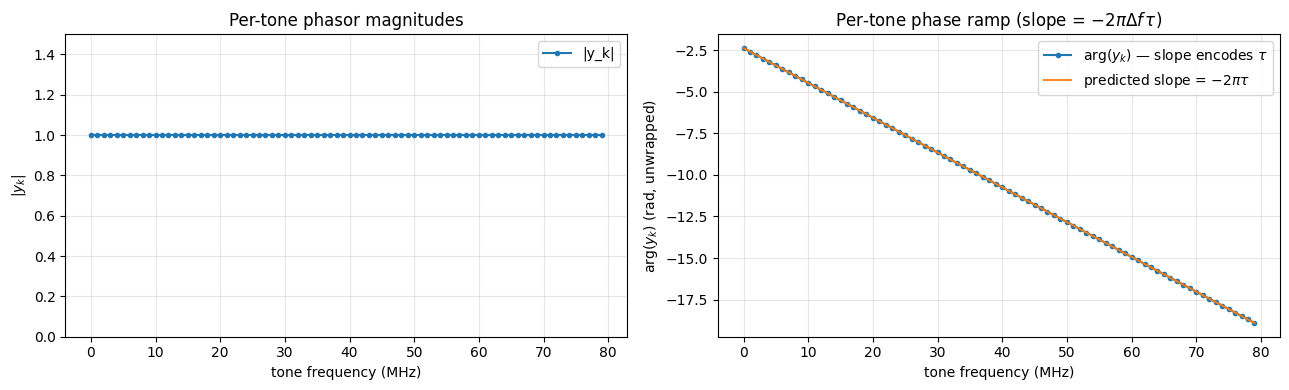

In [7]:
# 5. Per-tone phasor view of the recovered baseband
phasors_chan = np.fft.fft(y_BB)[:N] / M

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(np.arange(N) * delta_f / 1e6, np.abs(phasors_chan), '.-', label='|y_k|')
ax.set_ylim(0, 1.5)     
ax.set_xlabel('tone frequency (MHz)')
ax.set_ylabel(r'$|y_k|$')
ax.set_title('Per-tone phasor magnitudes')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
unwrapped = np.unwrap(np.angle(phasors_chan))
ax.plot(np.arange(N) * delta_f / 1e6, unwrapped, '.-', label=r'arg($y_k$) — slope encodes $\tau$')
# Predicted slope: -2*pi*delta_f*tau per tone-index step
predicted_slope_rad_per_Hz = -2 * np.pi * tau
ax.plot(np.arange(N) * delta_f / 1e6,
        unwrapped[0] + predicted_slope_rad_per_Hz * np.arange(N) * delta_f,
        '-', alpha=0.9, label=r'predicted slope = $-2\pi\tau$')
ax.set_xlabel('tone frequency (MHz)')
ax.set_ylabel('arg($y_k$) (rad, unwrapped)')
ax.set_title(r'Per-tone phase ramp (slope = $-2\pi\Delta f\,\tau$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. MUSIC distance estimation

Extract the per-tone phasors $y_k$ from the recovered baseband
(FFT bin $k$ for $k = 0, \dots, N-1$) and run MUSIC to recover $\hat d$.

**Algorithm** (single-path, no smoothing flexibility — kept compact for
this notebook):

1. **Forward spatial smoothing**: form $K = N - L + 1$ length-$L$
   subarrays from the $N$ phasors, average their outer products into
   the $L\times L$ sample covariance $\hat R$.
2. **Eigendecomposition** $\hat R = V\Lambda V^\top$. Sort eigenvalues
   descending. Take the top $P = 1$ eigenvector as the signal subspace,
   the remaining $L - 1$ as the noise subspace $V_n$.
3. **Pseudo-spectrum** on a fine distance grid:
   $P_{\text{MUSIC}}(d) = 1 / \|V_n^H\,a(d)\|^2$ with steering vector
   $a(d) = [\exp(-j\,2\pi\,l\,\Delta f\,d/c)]_{l=0}^{L-1}$.
4. **Peak pick**: $\hat d = \arg\max_d P_{\text{MUSIC}}(d)$.

The unambiguous range is bounded by the tone spacing:
$d_{\max} = c / (2\,\Delta f) = 150$ m at $\Delta f = 1$ MHz.

True distance      : 10.000 m
MUSIC estimate d_hat: 9.999 m
residual error     : -0.0007 m


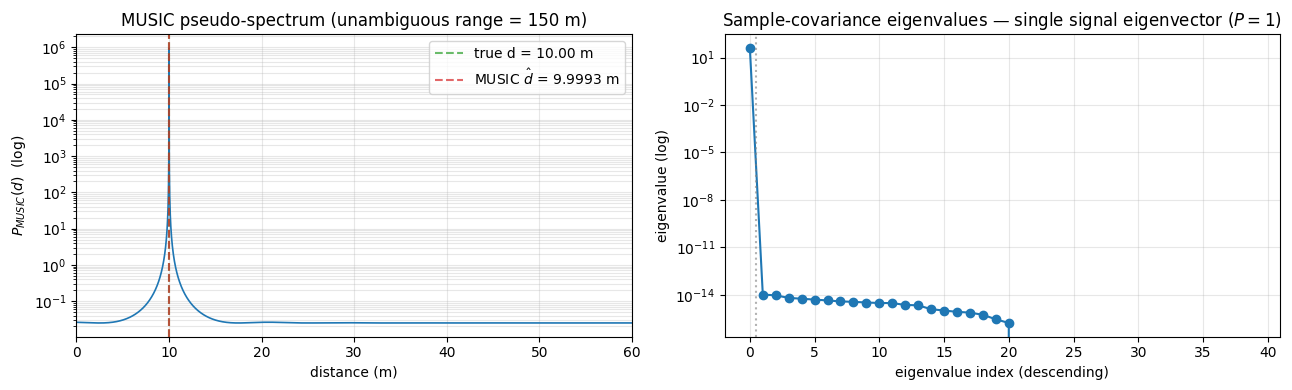

In [8]:
# 6. MUSIC distance estimation from the recovered phasors

def music_distance(y, delta_f, P=1, L=None, n_grid=10000, c_speed=2.998e8):
    """Single-symbol MUSIC. Returns (d_hat, d_grid, P_music, eigvals)."""
    Nt = len(y)
    if L is None:
        L = Nt // 2
    K = Nt - L + 1
    # Forward smoothed snapshot matrix (L, K)
    Y = np.column_stack([y[k:k + L] for k in range(K)])
    R = (Y @ Y.conj().T) / K
    eigvals, eigvecs = np.linalg.eigh(R)
    # eigh returns ascending; flip to descending
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]
    # Noise subspace
    Vn = eigvecs[:, P:]
    # Distance grid up to unambiguous limit
    d_max  = c_speed / (2 * delta_f)
    d_grid = np.linspace(0, d_max, n_grid)
    # Pseudo-spectrum
    spec = np.empty(n_grid)
    l_idx = np.arange(L)
    for i, d in enumerate(d_grid):
        a = np.exp(-1j * 2 * np.pi * l_idx * delta_f * (d / c_speed))
        spec[i] = 1.0 / (np.abs(Vn.conj().T @ a) ** 2).sum()
    return d_grid[np.argmax(spec)], d_grid, spec, eigvals


# Run MUSIC on the chained-and-delayed phasors
d_hat, d_grid, P_music, eigvals = music_distance(phasors_chan, delta_f)
print(f"True distance      : {d_true:.3f} m")
print(f"MUSIC estimate d_hat: {d_hat:.3f} m")
print(f"residual error     : {d_hat - d_true:+.4f} m")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pseudo-spectrum
ax = axes[0]
ax.semilogy(d_grid, P_music, linewidth=1.2)
ax.axvline(d_true, color='C2', linestyle='--', alpha=0.7, label=f'true d = {d_true:.2f} m')
ax.axvline(d_hat,  color='C3', linestyle='--', alpha=0.7, label=f'MUSIC $\\hat d$ = {d_hat:.4f} m')
ax.set_xlabel('distance (m)')
ax.set_ylabel(r'$P_{MUSIC}(d)$  (log)')
ax.set_title(f'MUSIC pseudo-spectrum (unambiguous range = {d_grid[-1]:.0f} m)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0, 60)   # zoom near the peak

# Eigenvalues
ax = axes[1]
ax.semilogy(np.arange(len(eigvals)), eigvals, 'o-')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('eigenvalue index (descending)')
ax.set_ylabel('eigenvalue (log)')
ax.set_title('Sample-covariance eigenvalues — single signal eigenvector ($P = 1$)')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Why $t_{TX}$ and $t_{RX}$ don't affect the distance estimate

Tracking the phase through the chain (Section 4) gave the closed form
$y_{BB}(t) = s_{BB}(t-\tau)\,\exp\!\bigl(j[\,2\pi\,\delta f\,t + \Delta\varphi - 2\pi f_{TX}\tau\,]\bigr)$
with

$$
\Delta\varphi \;=\; \underbrace{-2\pi f_{TX}\,t_{TX}}_{\text{Tx clock skew}} \;+\; \underbrace{2\pi f_{RX}\,t_{RX}}_{\text{Rx clock skew}} \;+\; \varphi_{TX} - \varphi_{RX}.
$$

Reading the FFT bin for tone $k$ (Section 5) gives

$$
y_k \;=\; \exp\!\bigl(-j\,2\pi\,k\,\Delta f\,\tau\bigr) \;\cdot\; \underbrace{\exp\!\bigl(j[\Delta\varphi - 2\pi f_{TX}\tau]\bigr)}_{\text{constant in } k}.
$$

So the per-tone phase splits cleanly into two pieces:

| component                         | depends on                                                  | role             |
| --------------------------------- | ----------------------------------------------------------- | ---------------- |
| **slope** $-2\pi\,\Delta f\,\tau$ | only $\tau$                                                 | encodes distance |
| **intercept** (everything else)   | $t_{TX},\,t_{RX},\,\varphi_{TX},\,\varphi_{RX},\,f_{TX}\tau$ | absorbed         |

Both MUSIC and slope-fit estimate $\tau$ from the **slope** of the phase
ramp across tones, and both are blind to a global phase rotation:

- **MUSIC** because the sample covariance $\hat R = \tfrac{1}{K}\sum y\,y^H$
  satisfies $(e^{j\theta}y)(e^{j\theta}y)^H = y\,y^H$, so multiplying every
  phasor by the same $e^{j\theta}$ leaves $\hat R$ — and therefore the
  eigenvectors and the entire pseudo-spectrum — bit-identical.
- **Slope-fit** because adding a constant to every $\arg(y_k)$ leaves the
  slope of the linear fit untouched.

The deeper reason $t_{TX}$ behaves this way is that **the LO is a single
tone**. Time-shifting a sinusoid is the same as rotating its phase:

$$
\exp\!\bigl(j\,2\pi f_{TX}(t - t_{TX})\bigr) \;=\; \underbrace{\exp(-j\,2\pi f_{TX}\,t_{TX})}_{\text{constant phase}} \cdot \exp(j\,2\pi f_{TX}\,t).
$$

So $t_{TX}$ is mathematically indistinguishable from a shift in
$\varphi_{TX}$ — it just relabels the LO's zero-phase moment, and the
same constant rotation lands on every baseband tone. The same argument
applies to $t_{RX}$.

Contrast this with the **propagation delay $\tau$**, which shifts the
*entire* RF waveform — carrier *plus* the multi-tone modulation. That
delay therefore splits into:

- a constant carrier-phase rotation $-2\pi f_{TX}\tau$ (joins the intercept), **and**
- a per-tone time shift on $s_{BB}$ that produces the $-2\pi k\,\Delta f\,\tau$ ramp.

It's only that second term — the time-shift acting on a *broadband*
baseband signal — that survives as a tone-dependent phase, and that's
what lets the chain measure $\tau$ at all. The LO clock skews don't have
a broadband signal to act on, so they collapse into the intercept and
vanish from the distance estimate.

**Empirical confirmation.** Sweeping $t_{TX} \in \{0,\,0.5,\,5,\,42,\,137,\,-23\}$ ns
(all other parameters held fixed) leaves $\hat d$ from MUSIC pinned at
the same value — the MUSIC pseudo-spectrum is literally identical
across these runs. The intercept of $\arg(y_k)$ moves with $t_{TX}$ as
$-2\pi f_{TX}\,t_{TX}\;(\bmod\,2\pi)$, exactly as predicted, but the
slope is invariant.

> **Caveat.** This invariance is a property of the *narrowband*
> single-tone LO model used here. A real Tx/Rx pair has finite group
> delay through filters and the analog front end; if those vary across
> the 80-MHz tone grid, the resulting frequency-dependent phase response
> *will* contribute a slope and bias the distance estimate. What's
> invariant here is specifically the **LO clock skew** — a pure time
> shift of an ideal single-frequency carrier.

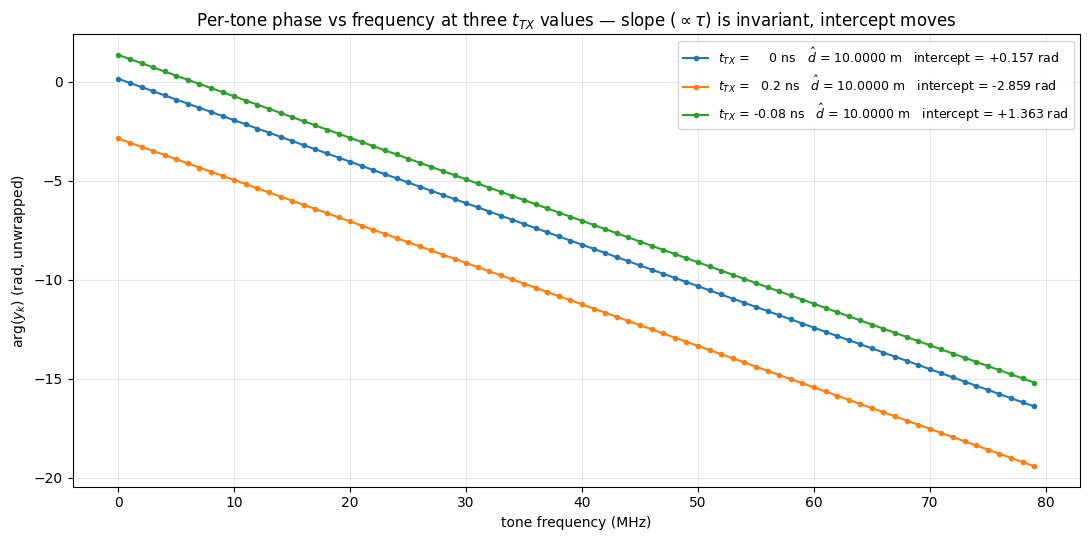

In [9]:
# 7. Per-tone phase across frequency, swept over t_TX
def run_chain(t_TX_val):
    """Re-run upconvert -> channel -> downconvert -> LPF with a given t_TX.
    All other parameters (f_LO, delta_f_*, t_RX, phi_*, tau) come from the
    notebook scope. Returns the per-tone baseband phasors y_k."""
    f_TX_v = f_LO + delta_f_TX
    f_RX_v = f_LO + delta_f_RX
    lo_TX_v = np.exp(1j * (2 * np.pi * f_TX_v * (t - t_TX_val) + phi_TX))
    s_RF_v  = np.real(s_BB * lo_TX_v)
    s_RF_rx_v = np.real(np.fft.ifft(np.fft.fft(s_RF_v) *
                                    np.exp(-1j * 2 * np.pi * freqs * tau)))
    lo_RX_v = np.exp(-1j * (2 * np.pi * f_RX_v * (t - t_RX) + phi_RX))
    y_mixed_v = s_RF_rx_v * 2 * lo_RX_v
    Y_BB_v = np.fft.fft(y_mixed_v).copy()
    Y_BB_v[np.abs(freqs) > cutoff] = 0.0
    y_BB_v = np.fft.ifft(Y_BB_v)
    return np.fft.fft(y_BB_v)[:N] / M


t_TX_sweep_ns  = [0.0, 0.2, -0.08]  # Tx LO time shift values to sweep, ns
tone_freqs_MHz = np.arange(N) * delta_f / 1e6
tone_freqs_Hz  = np.arange(N) * delta_f

fig, ax = plt.subplots(figsize=(11, 5.5))
for t_TX_v_ns in t_TX_sweep_ns:
    phasors = run_chain(t_TX_v_ns * 1e-9)
    arg     = np.unwrap(np.angle(phasors))
    slope, intercept = np.polyfit(tone_freqs_Hz, arg, 1)
    d_fit   = -slope / (2 * np.pi) * c
    ax.plot(tone_freqs_MHz, arg, '.-',
            label=(fr'$t_{{TX}}$ = {t_TX_v_ns:>5g} ns   '
                   fr'$\hat d$ = {d_fit:.4f} m   '
                   fr'intercept = {intercept:+.3f} rad'))

ax.set_xlabel('tone frequency (MHz)')
ax.set_ylabel(r'$\arg(y_k)$ (rad, unwrapped)')
ax.set_title(r'Per-tone phase vs frequency at three $t_{TX}$ values — '
             r'slope ($\propto \tau$) is invariant, intercept moves')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Note: t_TX is only meaningful modulo the LO
# period 1/f_TX ~ 417 ps; integer-cycle differences are invisible.